# Supplemental Figures

Boxplots comparing cyanogenic glycoside abundance between control and fermented samples (cassava feature 480, cocoyam feature 475). ClassyFire superclass violin plots showing intensity distributions across chemical superclasses (Cassava and Cocoyam). Forest plots showing NPC chemical class enrichment with median log2 fold-change and FDR-adjusted significance.

**Outputs:** `supplemental_cocoyam_features.svg/.png`, `supplemental_classyfire_superclass.svg/.png`, `supplemental_npc_significance_forest.svg/.png`

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import textwrap
import os
from scipy.stats import mannwhitneyu
from matplotlib.patches import Patch

# ─── Style (matches publication figures) ─────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'

LABEL_FONTSIZE      = 20
TICK_FONTSIZE       = 20
LEGEND_FONTSIZE     = 18
PANEL_LABEL_FONTSIZE = 28
SPINE_WIDTH         = 2.5
GRID_ALPHA          = 0.25
BOX_ALPHA           = 0.85
PROB_CUTOFF         = 0.64

CASSAVA_COLORS = {'Control': '#4A8FA0', 'Fermented': '#D4C020'}

OUTPUT_DIR = '../figures/separate_treatment'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Style ready.')


Style ready.


In [7]:
# ── Load cassava data ─────────────────────────────────────────────────────────
cassava_quant = pd.read_csv('../results/b3_cassavaonly_feature_list_imputed_log2.csv')
cassava_fdr   = pd.read_csv('../results/b3_cassavaonly_fdr_cassava_vs_fermented_cassava.csv')
cassava_ms2   = pd.read_csv('../results/b3_cassavaonly_ms2_annotations.csv')

# ── Merge quant with MS2 annotations ──────────────────────────────────────────
cassava_violin_data = cassava_quant.merge(
    cassava_ms2.rename(columns={'mappingFeatureId': 'id'}),
    on='id',
    how='inner'
)

# ── Sample columns ─────────────────────────────────────────────────────────────
ctrl_cols = [f"CSF_1_rep_{r}_norm_log2" for r in (1, 2, 3)]
ferm_cols = [f"CSF_2_rep_{r}_norm_log2" for r in (1, 2, 3)]

print(f"Cassava features with MS2: {len(cassava_violin_data):,}")


Cassava features with MS2: 1,428


Valid ClassyFire superclasses: 8
['Organic oxygen compounds', 'Lipids and lipid-like molecules', 'Organoheterocyclic compounds', 'Organic acids and derivatives', 'Phenylpropanoids and polyketides', 'Benzenoids', 'Organic nitrogen compounds', 'Nucleosides, nucleotides, and analogues']


/tmp/ipykernel_232618/2879960778.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: ../figures/separate_treatment/supplemental_classyfire_superclass.svg/.png


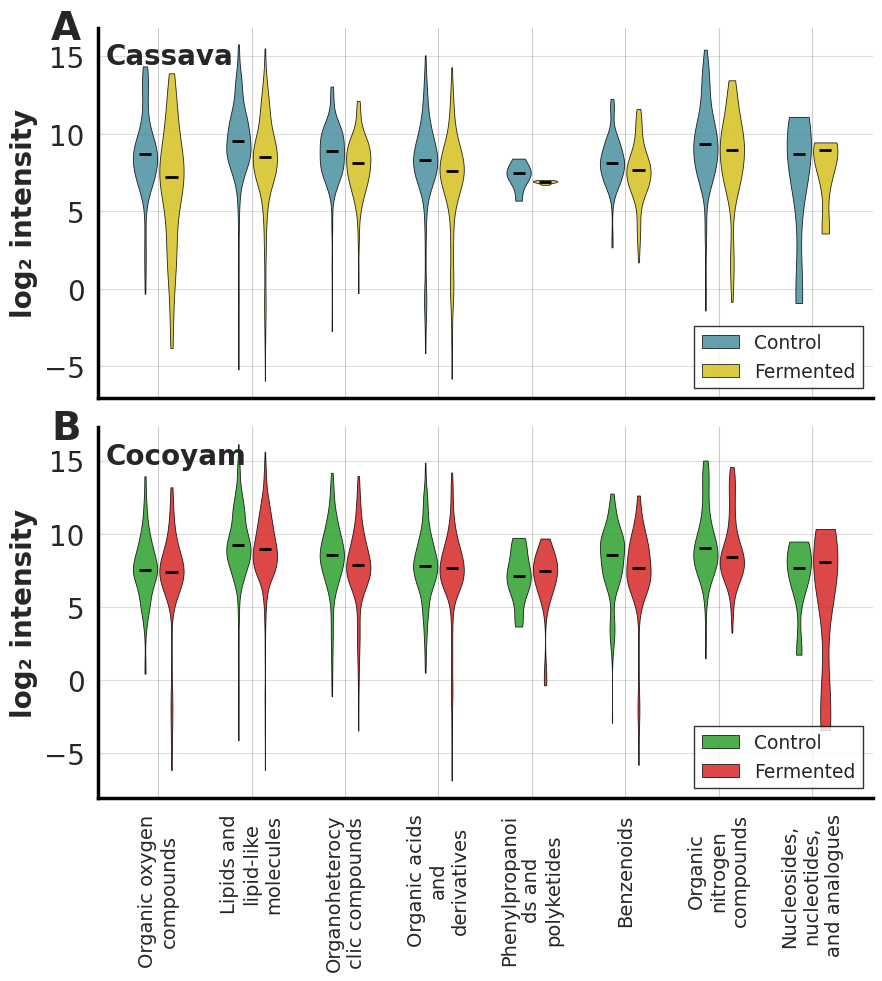

In [8]:
# ── Supplemental: ClassyFire Superclass Violin Plots ─────────────────────────
# Two-row layout: Cassava (top), Cocoyam (bottom).
# Each violin shows log2-normalized intensity distribution per ClassyFire
# superclass, split by Control vs. Fermented.
# Only classes with ≥ 5 features in all four condition/tuber groups are shown.
# Ordered by ascending median log2FC in cassava.

import textwrap
from matplotlib.patches import Patch

CLASS_COL = "sirius_ClassyFire#superclass"
PROB_COL  = "sirius_ClassyFire#superclass probability"
MIN_N     = 5

cs_ctrl_cols = [f"CSF_1_rep_{r}_norm_log2" for r in (1, 2, 3)]
cs_ferm_cols = [f"CSF_2_rep_{r}_norm_log2" for r in (1, 2, 3)]
cy_ctrl_cols = [f"CYF_1_rep_{r}_norm_log2" for r in (1, 2, 3)]
cy_ferm_cols = [f"CYF_2_rep_{r}_norm_log2" for r in (1, 2, 3)]

# Re-load cocoyam violin data (merge quant + annotations)
cy_quant_v = pd.read_csv('../results/b3_cocoyamonly_feature_list_imputed_log2.csv')
cy_ms2_v   = pd.read_csv('../results/b3_cocoyamonly_ms2_annotations.csv')
cocoyam_violin_data = cy_quant_v.merge(
    cy_ms2_v.rename(columns={'mappingFeatureId': 'id'}),
    on='id', how='inner'
)

rows_def = [
    {
        'label' : 'Cassava',
        'source': cassava_violin_data,
        'ctrl'  : cs_ctrl_cols,
        'ferm'  : cs_ferm_cols,
        'colors': ['#4A8FA0', '#D4C020'],
    },
    {
        'label' : 'Cocoyam',
        'source': cocoyam_violin_data,
        'ctrl'  : cy_ctrl_cols,
        'ferm'  : cy_ferm_cols,
        'colors': ['#2ca02c', '#d62728'],
    },
]

def build_long(source, cols, class_col, prob_col):
    sub = source[
        (pd.to_numeric(source[prob_col], errors='coerce') >= PROB_CUTOFF) &
        source[class_col].notna() & (source[class_col] != '')
    ][[class_col] + cols].copy()
    long = sub.melt(id_vars=class_col, value_vars=cols, value_name='intensity')
    long['intensity'] = pd.to_numeric(long['intensity'], errors='coerce')
    return long.dropna(subset=['intensity'])

for row in rows_def:
    row['ctrl_long'] = build_long(row['source'], row['ctrl'], CLASS_COL, PROB_COL)
    row['ferm_long'] = build_long(row['source'], row['ferm'], CLASS_COL, PROB_COL)

# Classes present in all four condition/tuber groups with >= MIN_N features
all_classes = set()
for row in rows_def:
    all_classes |= set(row['ctrl_long'][CLASS_COL].unique())
    all_classes |= set(row['ferm_long'][CLASS_COL].unique())

valid_classes = [
    c for c in all_classes
    if all(
        (row[k][CLASS_COL] == c).sum() >= MIN_N
        for row in rows_def
        for k in ['ctrl_long', 'ferm_long']
    )
]

def median_diff(cls):
    ctrl = rows_def[0]['ctrl_long'].loc[rows_def[0]['ctrl_long'][CLASS_COL] == cls, 'intensity']
    ferm = rows_def[0]['ferm_long'].loc[rows_def[0]['ferm_long'][CLASS_COL] == cls, 'intensity']
    return ferm.median() - ctrl.median()

class_order = sorted(valid_classes, key=median_diff)
n_classes   = len(class_order)
print(f"Valid ClassyFire superclasses: {n_classes}")
print(class_order)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 1,
    figsize=(max(10, n_classes * 1.2), 10),
    sharex=True,
    gridspec_kw={'hspace': 0.08}
)

centres = np.arange(n_classes) * 3.0

for ax_i, (ax, row) in enumerate(zip(axes, rows_def)):
    for gi, cls in enumerate(class_order):
        for ti, (key, color) in enumerate(zip(['ctrl_long', 'ferm_long'], row['colors'])):
            vals = row[key].loc[row[key][CLASS_COL] == cls, 'intensity'].values
            if len(vals) < 2:
                continue
            pos = centres[gi] + (ti - 0.5) * 0.85
            parts = ax.violinplot(
                [vals], positions=[pos],
                widths=0.78,
                showmeans=False, showmedians=True, showextrema=False
            )
            for pc in parts['bodies']:
                pc.set_facecolor(color)
                pc.set_edgecolor('black')
                pc.set_linewidth(0.6)
                pc.set_alpha(BOX_ALPHA)
            parts['cmedians'].set_color('black')
            parts['cmedians'].set_linewidth(2.0)

    ax.set_ylabel('log\u2082 intensity', fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.tick_params(axis='y', labelsize=TICK_FONTSIZE, width=SPINE_WIDTH, length=6)
    ax.spines[['top', 'right']].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_linewidth(SPINE_WIDTH)
        ax.spines[spine].set_edgecolor('black')
    ax.grid(axis='y', alpha=GRID_ALPHA, linewidth=0.8, linestyle='-', color='gray')
    ax.set_axisbelow(True)

    # Condition legend — bottom right
    ax.legend(
        handles=[
            Patch(facecolor=c, edgecolor='black', linewidth=0.6, alpha=BOX_ALPHA, label=l)
            for c, l in zip(row['colors'], ['Control', 'Fermented'])
        ],
        fontsize=LEGEND_FONTSIZE * 0.75,
        frameon=True, fancybox=False, edgecolor='black', shadow=False,
        loc='lower right'
    )

    # Panel letter
    panel_letter = 'A' if ax_i == 0 else 'B'
    ax.text(-0.06, 1.05, panel_letter, transform=ax.transAxes,
            fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

    # Tuber name — just above axes, upper left
    ax.text(0.01, 0.96, row['label'], transform=ax.transAxes,
            fontsize=LABEL_FONTSIZE, fontweight='bold', va='top')

# x-axis labels at 90 degrees, on bottom panel only
axes[1].set_xticks(centres)
axes[1].set_xticklabels(
    ['\n'.join(textwrap.wrap(c, width=14)) for c in class_order],
    rotation=90, ha='center', fontsize=TICK_FONTSIZE * 0.7
)
axes[1].tick_params(axis='x', width=SPINE_WIDTH, length=8)

fig.tight_layout()

out_stem = f"{OUTPUT_DIR}/supplemental_classyfire_superclass"
fig.savefig(f"{out_stem}.svg", format='svg', bbox_inches='tight')
fig.savefig(f"{out_stem}.png", dpi=300, bbox_inches='tight')
print(f"Saved: {out_stem}.svg/.png")
plt.show()

Saved: ../figures/separate_treatment/supplemental_cocoyam_features.svg/.png


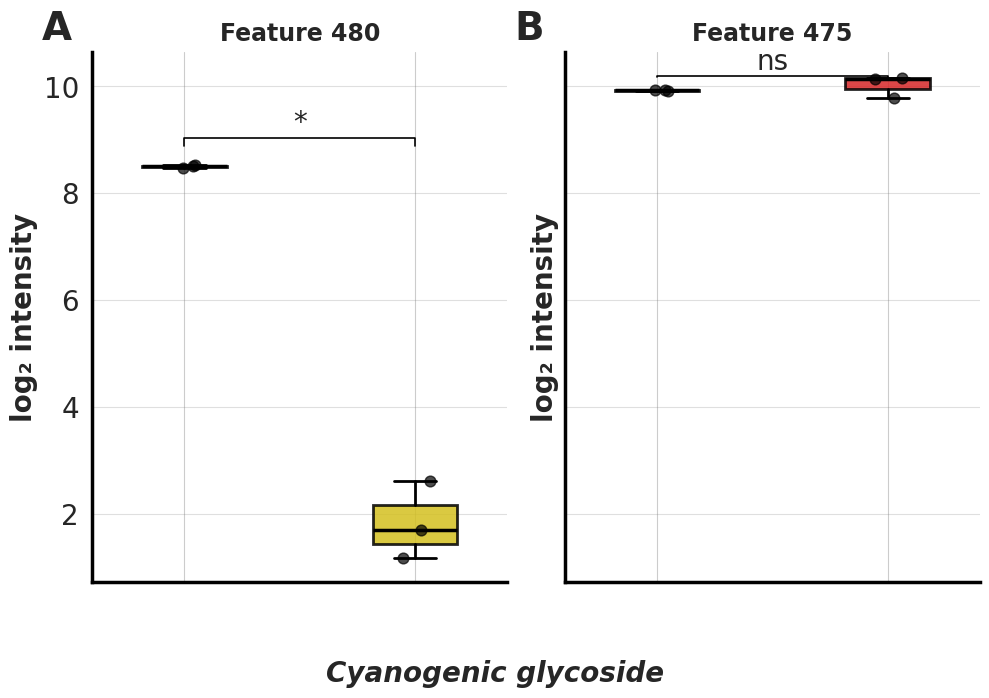

In [9]:
# ── Supplemental: Cocoyam features 480 and 475 boxplots ─────────────────────
import textwrap

cy_quant = pd.read_csv('../results/b3_cocoyamonly_feature_list_imputed_log2.csv')
cy_fdr   = pd.read_csv('../results/b3_cocoyamonly_fdr_cocoyam_vs_fermented_cocoyam.csv')

cy_ctrl_cols = [f'CYF_1_rep_{r}_norm_log2' for r in (1,2,3)]
cy_ferm_cols = [f'CYF_2_rep_{r}_norm_log2' for r in (1,2,3)]
COCOYAM_COLORS = {'Control': '#2ca02c', 'Fermented': '#d62728'}

def get_vals_and_sig(fid):
    row  = cy_quant[cy_quant['id'] == fid].iloc[0]
    pval = float(cy_fdr[cy_fdr['id'] == fid].iloc[0]['p.value'])
    sig  = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    ctrl = pd.to_numeric(row[cy_ctrl_cols], errors='coerce').values
    ferm = pd.to_numeric(row[cy_ferm_cols], errors='coerce').values
    return ctrl, ferm, sig, pval

# ── Cassava feature 480 ──────────────────────────────────────────────────────
cs_quant = pd.read_csv('../results/b3_cassavaonly_feature_list_imputed_log2.csv')
cs_fdr   = pd.read_csv('../results/b3_cassavaonly_fdr_cassava_vs_fermented_cassava.csv')
cs_ctrl_cols = [f'CSF_1_rep_{r}_norm_log2' for r in (1,2,3)]
cs_ferm_cols = [f'CSF_2_rep_{r}_norm_log2' for r in (1,2,3)]
CASSAVA_COLORS = {'Control': '#4A8FA0', 'Fermented': '#D4C020'}

def get_cassava_vals(fid):
    row  = cs_quant[cs_quant['id'] == fid].iloc[0]
    pval = float(cs_fdr[cs_fdr['id'] == fid].iloc[0]['p.value'])
    sig  = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    ctrl = pd.to_numeric(row[cs_ctrl_cols], errors='coerce').values
    ferm = pd.to_numeric(row[cs_ferm_cols], errors='coerce').values
    return ctrl, ferm, sig

panels = [
    (480, 'A', 'Feature 480', 'cassava'),
    (475, 'B', 'Feature 475', 'cocoyam'),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 6.5), sharey=True)
x_pos = np.array([0.0, 1.5])
conditions = ['Control', 'Fermented']

for ax, (fid, panel_letter, title, tuber) in zip(axes, panels):
    if tuber == 'cassava':
        ctrl_v, ferm_v, sig = get_cassava_vals(fid)
        colors = CASSAVA_COLORS
    else:
        ctrl_v, ferm_v, sig, _ = get_vals_and_sig(fid)
        colors = COCOYAM_COLORS
    all_vals = [ctrl_v, ferm_v]

    bp = ax.boxplot(
        all_vals,
        positions=x_pos,
        widths=0.55,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2.5),
        whiskerprops=dict(linewidth=SPINE_WIDTH * 0.8),
        capprops=dict(linewidth=SPINE_WIDTH * 0.8),
        boxprops=dict(linewidth=SPINE_WIDTH * 0.8),
        flierprops=dict(marker='o', markersize=4, alpha=0.5,
                        markeredgecolor='black', markerfacecolor='none'),
        showfliers=True,
    )
    for patch, cond in zip(bp['boxes'], conditions):
        patch.set_facecolor(colors[cond])
        patch.set_alpha(BOX_ALPHA)

    # Jittered points
    rng = np.random.default_rng(42)
    for xi, vals in enumerate(all_vals):
        jitter = rng.uniform(-0.1, 0.1, size=len(vals))
        ax.scatter(np.full(len(vals), x_pos[xi]) + jitter, vals,
                   color='black', s=60, zorder=4, alpha=0.7)

    # Significance bracket
    y_max     = max(ctrl_v.max(), ferm_v.max())
    y_range   = y_max - min(ctrl_v.min(), ferm_v.min())
    bracket_y = y_max + y_range * 0.05
    tick_h    = y_range * 0.02
    ax.plot([x_pos[0], x_pos[0], x_pos[1], x_pos[1]],
            [bracket_y, bracket_y + tick_h, bracket_y + tick_h, bracket_y],
            color='black', linewidth=1.2)
    ax.text(np.mean(x_pos), bracket_y + tick_h * 1.2, sig,
            ha='center', va='bottom', fontsize=TICK_FONTSIZE)

    # No x-tick labels, no xlabel
    ax.set_xticks(x_pos)
    ax.set_xticklabels([], fontsize=TICK_FONTSIZE)
    ax.set_xlim(-0.6, 2.1)
    ax.set_ylabel('log\u2082 intensity', fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.set_title(title, fontsize=LABEL_FONTSIZE * 0.85, fontweight='bold', pad=8)
    ax.tick_params(axis='y', labelsize=TICK_FONTSIZE, width=SPINE_WIDTH, length=6)
    ax.tick_params(axis='x', width=SPINE_WIDTH, length=6)
    ax.spines[['top', 'right']].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_linewidth(SPINE_WIDTH)
        ax.spines[spine].set_edgecolor('black')
    ax.grid(axis='y', alpha=GRID_ALPHA, linewidth=0.8, linestyle='-', color='gray')
    ax.set_axisbelow(True)

    # Panel letter
    ax.text(-0.12, 1.08, panel_letter, transform=ax.transAxes,
            fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top', ha='left')

# Shared "Cyanogenic glycoside" label centered below both panels
fig.text(0.5, -0.02, 'Cyanogenic glycoside', ha='center', va='top',
         fontsize=LABEL_FONTSIZE, fontweight='bold', style='italic')

fig.tight_layout()
fig.subplots_adjust(bottom=0.10)

out_stem = f"{OUTPUT_DIR}/supplemental_cocoyam_features"
fig.savefig(f"{out_stem}.svg", format='svg', bbox_inches='tight')
fig.savefig(f"{out_stem}.png", dpi=300, bbox_inches='tight')
print(f"Saved: {out_stem}.svg/.png")
plt.show()


Cocoyam features with MS2: 1,839
Saved: ../figures/separate_treatment/supplemental_npc_significance_forest.svg/.png


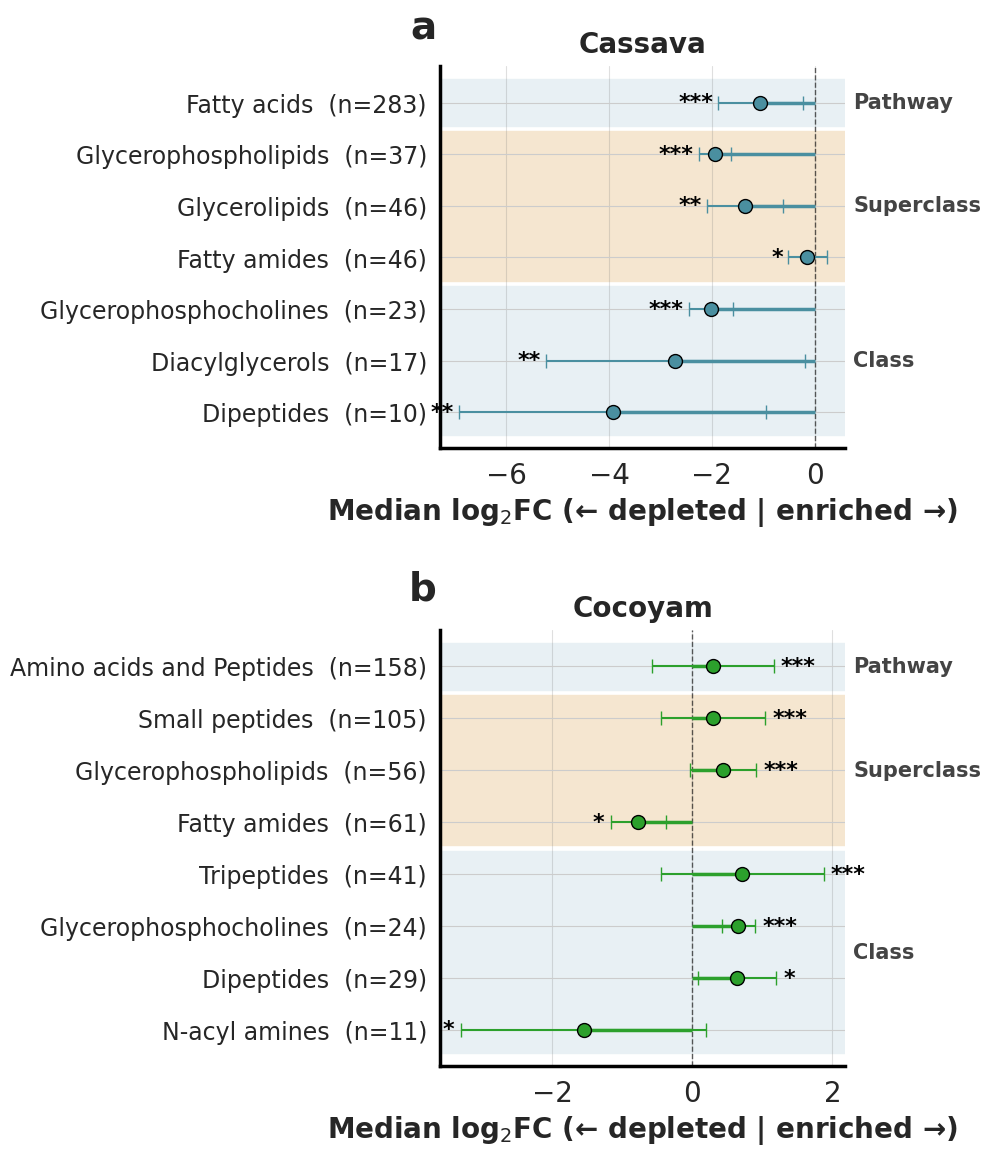

In [10]:
# == Supplemental: NPC Significance Forest Plot (stacked panels) ===============
# Panel a: Cassava (top), Panel b: Cocoyam (bottom).
# Horizontal lollipop from 0 to median log2FC. Publication style from figure 2.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import iqr as scipy_iqr

# == Load cocoyam data =========================================================
cocoyam_quant = pd.read_csv('../results/b3_cocoyamonly_feature_list_imputed_log2.csv')
cocoyam_ms2   = pd.read_csv('../results/b3_cocoyamonly_ms2_annotations.csv')
cocoyam_violin_data = cocoyam_quant.merge(
    cocoyam_ms2.rename(columns={'mappingFeatureId': 'id'}),
    on='id', how='inner'
)
print(f'Cocoyam features with MS2: {len(cocoyam_violin_data):,}')

npc_sig = pd.read_csv('../results/canopus_npc_significance.csv')
SIG_ALPHA = 0.05

# == Publication style ==========================================================
LABEL_FONTSIZE       = 20
TICK_FONTSIZE        = 20
LEGEND_FONTSIZE      = 18
PANEL_LABEL_FONTSIZE = 28
SPINE_WIDTH          = 2.5
GRID_ALPHA           = 0.25

TUBER_COLORS = {'Cassava': '#4A8FA0', 'Cocoyam': '#2ca02c'}
NPC_PROB_CUTOFF = 0.64

DATAS = {'Cassava': cassava_violin_data, 'Cocoyam': cocoyam_violin_data}

NPC_COLS = {
    'pathway':    ('sirius_NPC#pathway',    'sirius_NPC#pathway Probability'),
    'superclass': ('sirius_NPC#superclass', 'sirius_NPC#superclass Probability'),
    'class':      ('sirius_NPC#class',      'sirius_NPC#class Probability'),
}

REP_COLS = {
    'Cassava': {
        'ctrl': [f'CSF_1_rep_{r}_norm_log2' for r in (1,2,3)],
        'ferm': [f'CSF_2_rep_{r}_norm_log2' for r in (1,2,3)],
    },
    'Cocoyam': {
        'ctrl': [f'CYF_1_rep_{r}_norm_log2' for r in (1,2,3)],
        'ferm': [f'CYF_2_rep_{r}_norm_log2' for r in (1,2,3)],
    },
}

LEVELS = [
    ('pathway',    'Pathway'),
    ('superclass', 'Superclass'),
    ('class',      'Class'),
]

def get_feature_log2fc(tuber, class_col, prob_col, cls_name):
    df = DATAS[tuber]
    mask = (
        (pd.to_numeric(df[prob_col], errors='coerce') >= NPC_PROB_CUTOFF) &
        (df[class_col] == cls_name)
    )
    sub = df.loc[mask]
    if sub.empty:
        return np.array([])
    ctrl = pd.to_numeric(sub[REP_COLS[tuber]['ctrl']].stack(), errors='coerce').unstack().mean(axis=1)
    ferm = pd.to_numeric(sub[REP_COLS[tuber]['ferm']].stack(), errors='coerce').unstack().mean(axis=1)
    return (ferm - ctrl).dropna().values

def sig_label(adjp):
    if adjp < 0.001: return '***'
    if adjp < 0.01:  return '**'
    if adjp < 0.05:  return '*'
    return ''

# == Collect data per tuber =====================================================
panel_data = {}
for tuber in ['Cassava', 'Cocoyam']:
    entries = []
    for level, level_label in LEVELS:
        class_col, prob_col = NPC_COLS[level]
        sig_rows = npc_sig.loc[
            (npc_sig['tuber'] == tuber) &
            (npc_sig['level'] == level) &
            (npc_sig['adjp'] < SIG_ALPHA)
        ].sort_values('adjp')
        for _, r in sig_rows.iterrows():
            fc_vals = get_feature_log2fc(tuber, class_col, prob_col, r['name'])
            if len(fc_vals) == 0:
                continue
            entries.append({
                'level': level_label,
                'name': r['name'],
                'median': np.median(fc_vals),
                'sem': scipy_iqr(fc_vals) / 2 if len(fc_vals) > 1 else 0,  # half-IQR as asymmetric spread
                'n': len(fc_vals),
                'sig': sig_label(r['adjp']),
            })
    panel_data[tuber] = entries

# == Figure: two rows, one per tuber ===========================================
n_cas = len(panel_data['Cassava'])
n_coc = len(panel_data['Cocoyam'])
row_h = 0.55  # inches per data row
pad   = 1.2   # extra padding per panel (title, x-axis, etc.)
fig_h = (n_cas + n_coc) * row_h + 2 * pad + 1.0
fig_w = 10

fig, axes = plt.subplots(2, 1, figsize=(fig_w, fig_h),
                         gridspec_kw={'height_ratios': [n_cas, n_coc]})

for ax, tuber, panel_letter in zip(axes, ['Cassava', 'Cocoyam'], ['a', 'b']):
    entries = panel_data[tuber]
    color = TUBER_COLORS[tuber]
    n_e = len(entries)
    y_pos = np.arange(n_e)[::-1]

    # Track levels for grouping
    level_y = {}
    for i, e in enumerate(entries):
        lv = e['level']
        if lv not in level_y:
            level_y[lv] = []
        level_y[lv].append(y_pos[i])

    # Draw lollipops
    sig_x_tips = []
    for i, e in enumerate(entries):
        y = y_pos[i]
        ax.hlines(y, 0, e['median'], color=color, linewidth=2.5, zorder=3)
        ax.errorbar(e['median'], y, xerr=e['sem'],
                    fmt='o', color=color, markersize=10, markeredgecolor='black',
                    markeredgewidth=1.0, elinewidth=1.5, capsize=5, capthick=1.2,
                    zorder=5)

        # Sig star
        if e['sig']:
            tip = e['median'] + e['sem'] if e['median'] >= 0 else e['median'] - e['sem']
            x_text = tip + (0.1 if e['median'] >= 0 else -0.1)
            ha = 'left' if e['median'] >= 0 else 'right'
            ax.text(x_text, y, e['sig'],
                    ha=ha, va='center', fontsize=TICK_FONTSIZE * 0.8,
                    fontweight='bold', color='black')
            sig_x_tips.append(x_text)

    # Vertical dashed line at 0
    ax.axvline(0, color='black', linewidth=1.0, linestyle='--', zorder=1, alpha=0.6)

    # Y-axis: class names with n
    ax.set_yticks(y_pos)
    ax.set_yticklabels(
        [f"{e['name']}  (n={e['n']})" for e in entries],
        fontsize=TICK_FONTSIZE * 0.85
    )
    ax.set_ylim(-0.7, n_e - 1 + 0.7)

    # Level group shading (alternating light backgrounds)
    shade_colors = ['#e8f0f4', '#f5e6d0']
    for si, (lv, yps) in enumerate(level_y.items()):
        y_lo = min(yps) - 0.45
        y_hi = max(yps) + 0.45
        ax.axhspan(y_lo, y_hi, color=shade_colors[si % 2], zorder=0)
        # Level label outside right edge
        ax.text(1.02, (min(yps) + max(yps)) / 2, lv,
                ha='left', va='center', fontsize=TICK_FONTSIZE * 0.75,
                fontweight='bold', color='#444444',
                transform=ax.get_yaxis_transform(), clip_on=False)

    # Expand xlim to fit sig stars
    xlo, xhi = ax.get_xlim()
    if sig_x_tips:
        xlo = min(xlo, min(sig_x_tips) - 0.20)
        xhi = max(xhi, max(sig_x_tips) + 0.20)
    ax.set_xlim(xlo, xhi)

    # X-axis
    ax.set_xlabel('Median log$_2$FC (← depleted | enriched →)',
                  fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.tick_params(axis='x', labelsize=TICK_FONTSIZE, width=SPINE_WIDTH, length=6)
    ax.tick_params(axis='y', labelsize=TICK_FONTSIZE * 0.85, width=SPINE_WIDTH, length=6)

    ax.spines[['top', 'right']].set_visible(False)
    for sp in ['left', 'bottom']:
        ax.spines[sp].set_linewidth(SPINE_WIDTH)
        ax.spines[sp].set_edgecolor('black')
    ax.grid(axis='x', alpha=GRID_ALPHA, linewidth=0.8, linestyle='-', color='gray')
    ax.set_axisbelow(True)

    # Title and panel letter
    ax.set_title(tuber, fontsize=LABEL_FONTSIZE, fontweight='bold', pad=10)
    ax.text(-0.01, 1.05, panel_letter, transform=ax.transAxes,
            fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='bottom', ha='right')

fig.tight_layout(h_pad=3)
fig.subplots_adjust(right=0.85, bottom=0.08)

out_stem = f'{OUTPUT_DIR}/supplemental_npc_significance_forest'
fig.savefig(f'{out_stem}.svg', format='svg', bbox_inches='tight')
fig.savefig(f'{out_stem}.png', dpi=300, bbox_inches='tight')
print(f'Saved: {out_stem}.svg/.png')
plt.show()
